In [3]:
import pickle
import numpy as np
import os


# ── Load saved results ────────────────────────────────────────────────────────
save_filename = 'Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0001_0441_saved_results.pkl'
save_path = r"C:\Users\smc241\OneDrive - University of Cambridge\StranksLab-CEB-107-112-WDO-2\Experiments\diamond\Beamtime Dec 2025\Pulse data\Sean_Sample\Shaping Pulse Analysis\Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0001_0441_saved_results.pkl"

with open(save_path, 'rb') as f:
    data = pickle.load(f)

centroid_results = data['centroid_results']
all_heights      = data['all_heights']
hdf5_files       = data['hdf5_files']

print(f'Loaded {len(centroid_results)} files')

Loaded 441 files


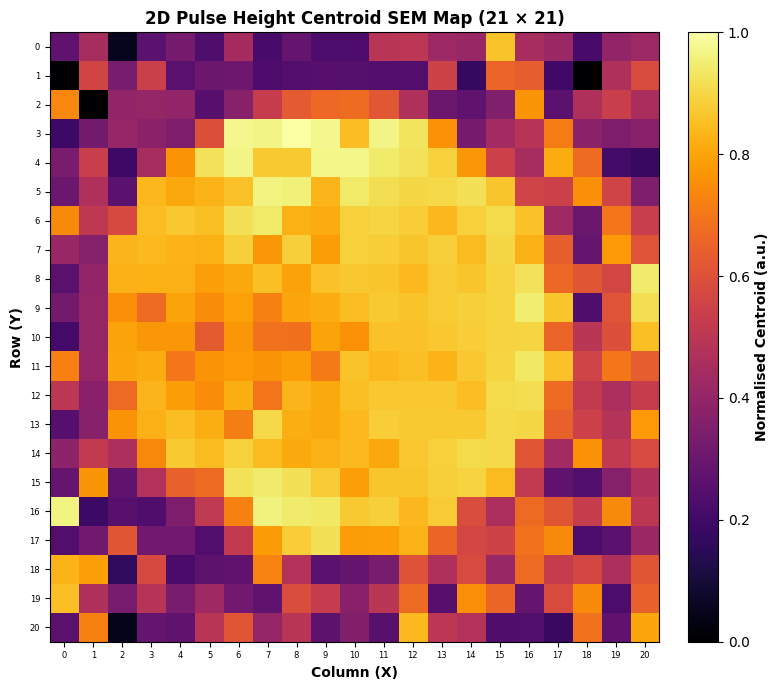

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Load csv ────────────────────────────────────────────────────────────────
csv_filename = r"C:\Users\smc241\OneDrive - University of Cambridge\StranksLab-CEB-107-112-WDO-2\Experiments\diamond\Beamtime Dec 2025\Pulse data\Sean_Sample\Shaping Pulse Analysis\Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0001_0441_centroids.csv"

df = pd.read_csv(csv_filename, header=0)

# ── Extract centroid column (column D = index 3) ──────────────────────────────
centroid_col = df.iloc[:, 3]  # Column D (0-indexed = 3)

# Replace 'no pulses' / 'FIT FAILED' strings with 0
centroids_raw = pd.to_numeric(centroid_col, errors='coerce').fillna(0).values

# ── Reshape into 21x21 ────────────────────────────────────────────────────────
assert len(centroids_raw) == 441, f'Expected 441 values, got {len(centroids_raw)}'
grid = centroids_raw.reshape(21, 21)

# ── Normalise [0, 1] ─────────────────────────────────────────────────────────
vmin = grid[grid > 0].min() if np.any(grid > 0) else 0   # ignore forced zeros in scaling
vmax = grid.max()
grid_norm = np.where(grid > 0, (grid - vmin) / (vmax - vmin), 0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7), tight_layout=True)

im = ax.imshow(grid_norm, cmap='inferno', vmin=0, vmax=1,
               origin='upper', aspect='equal', interpolation='nearest')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Normalised Centroid (a.u.)', fontweight='bold')

ax.set_xlabel('Column (X)',  fontweight='bold')
ax.set_ylabel('Row (Y)',     fontweight='bold')
ax.set_title('2D Pulse Height Centroid SEM Map (21 × 21)', fontweight='bold')

ax.set_xticks(range(21))
ax.set_yticks(range(21))
ax.set_xticklabels(range(21), fontsize=6)
ax.set_yticklabels(range(21), fontsize=6)

#plt.savefig('centroid_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

"""
CLARIFICATION GIVEN THERE IS A BUG IN THE NEXT CELL
The centroids are normalised then plotted. 
"""

C:\Users\smc241\AppData\Local\Temp\ipykernel_13736\2509606086.py:69: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gaussian, bin_centres[fit_mask], counts[fit_mask] / peak_count,
C:\Users\smc241\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\smc241\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


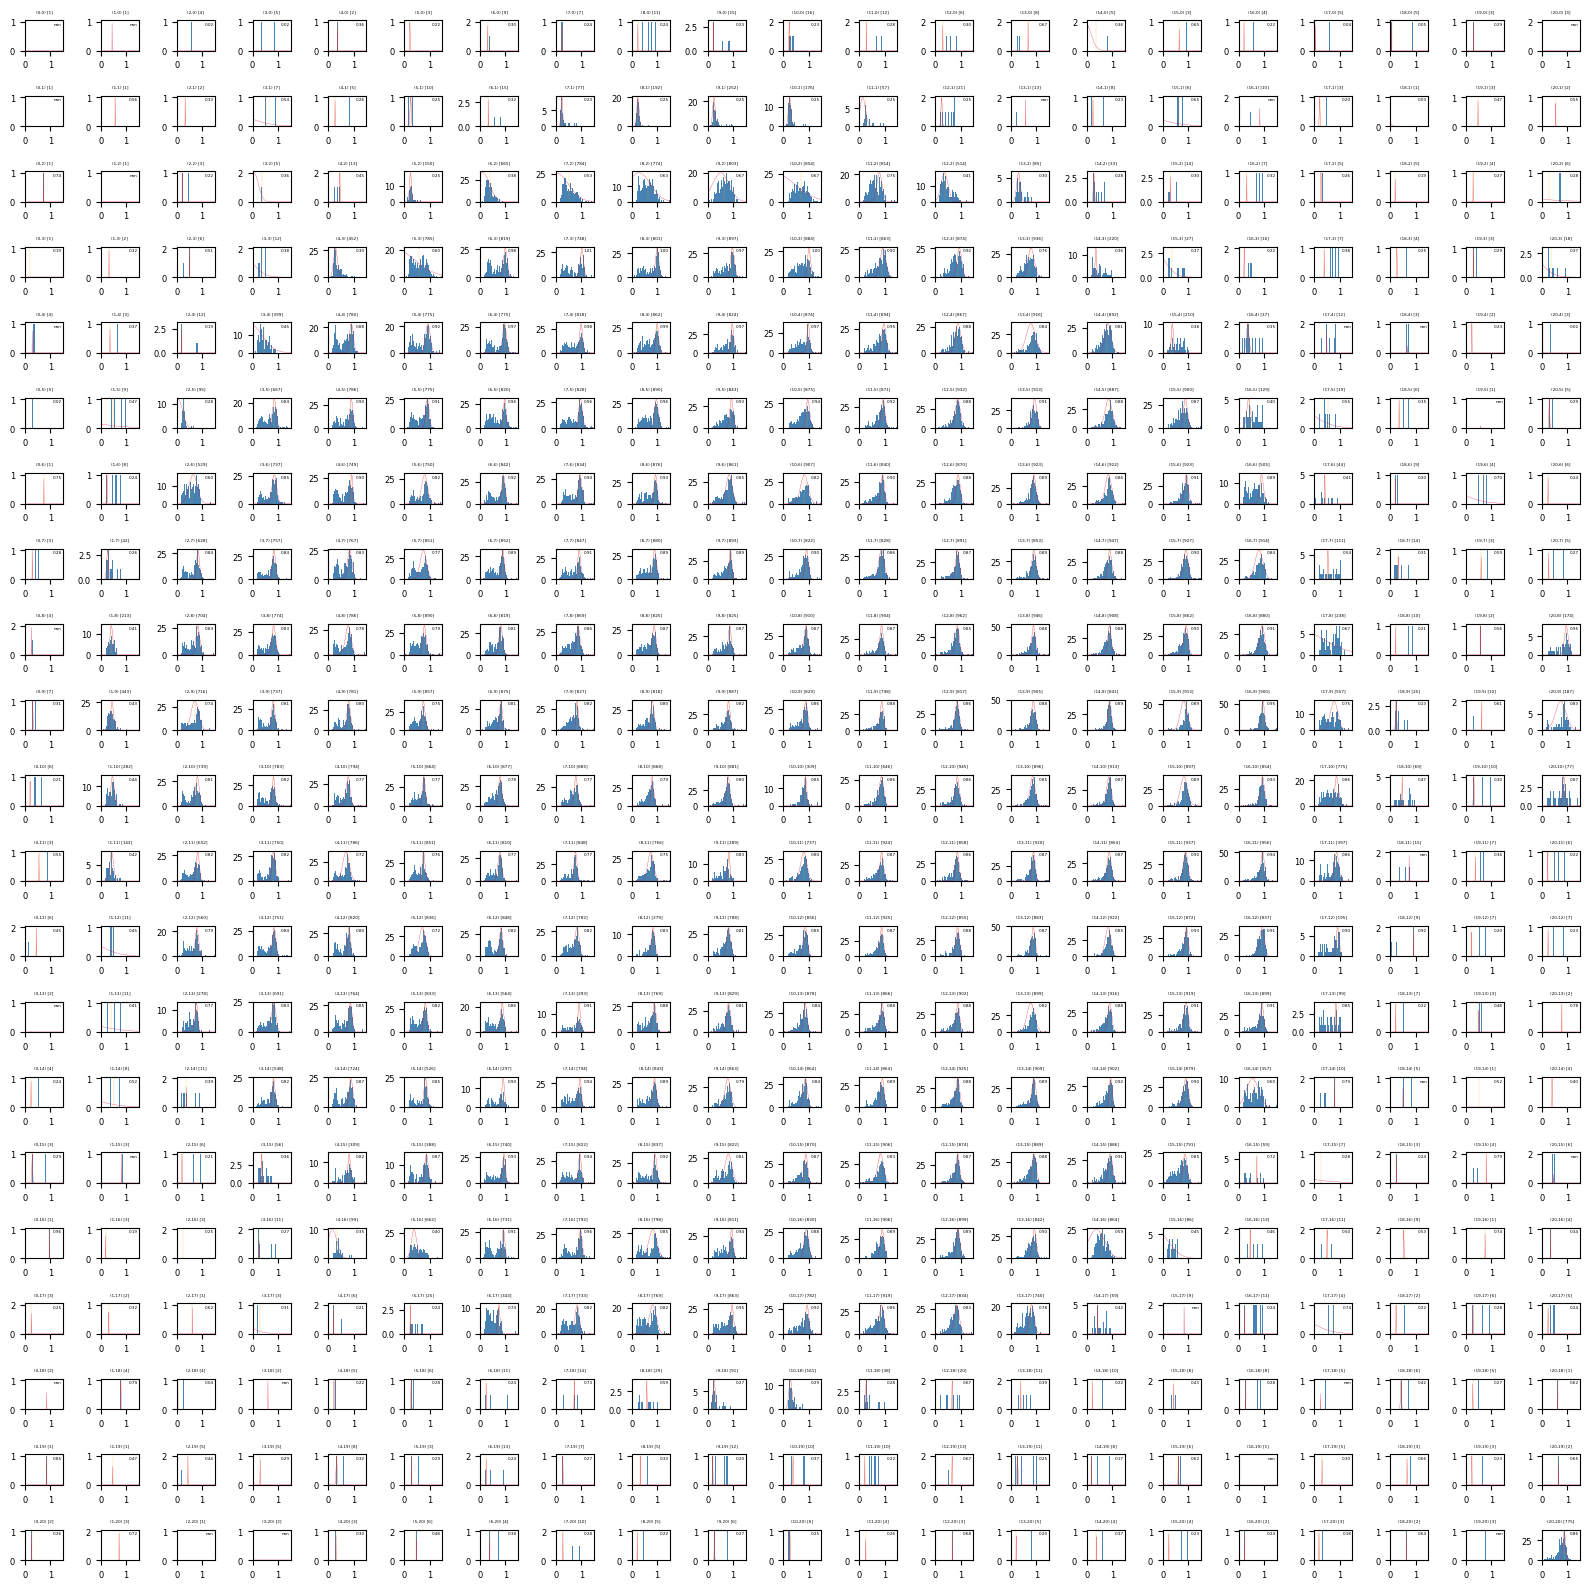

In [45]:
"""
BUG
the histograms are normalised first, 
and then the centroid is computed from the normalised spectra.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pickle
import pandas as pd
import textwrap

# ── Load saved results ────────────────────────────────────────────────────────
save_path = r"C:\Users\smc241\OneDrive - University of Cambridge\StranksLab-CEB-107-112-WDO-2\Experiments\diamond\Beamtime Dec 2025\Pulse data\Sean_Sample\Shaping Pulse Analysis\Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0001_0441_saved_results.pkl"
with open(save_path, 'rb') as f:
    data = pickle.load(f)
all_heights = data['all_heights']
hdf5_files  = data['hdf5_files']

# ── Load CSV to get same vmin/vmax as cell 2 ──────────────────────────────────
csv_filename = r"C:\Users\smc241\OneDrive - University of Cambridge\StranksLab-CEB-107-112-WDO-2\Experiments\diamond\Beamtime Dec 2025\Pulse data\Sean_Sample\Shaping Pulse Analysis\Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0001_0441_centroids.csv"
df = pd.read_csv(csv_filename, header=0)
centroids_raw = pd.to_numeric(df.iloc[:, 3], errors='coerce').fillna(0).values
grid = centroids_raw.reshape(21, 21)
vmin = grid[grid > 0].min() if np.any(grid > 0) else 0
vmax = grid.max()

def normalise(val):
    return (val - vmin) / (vmax - vmin)

def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def coord_to_idx(x, y, ncols=21):
    return y * ncols + x

# ── Normalised x-axis range ───────────────────────────────────────────────────
# Compute raw pulse height limits once across the whole dataset
all_values    = np.concatenate(list(all_heights.values()))
raw_data_max  = np.max(all_values)
# Normalised axis: 0 → vmin (mV), 1 → vmax (mV), mapped from raw pulse heights
# x_norm = (x_raw - vmin) / (vmax - vmin)
x_raw_plot    = np.linspace(0, raw_data_max, 500)
x_norm_plot   = normalise(x_raw_plot)  # for plotting the Gaussian curve

# ── Coords to plot ────────────────────────────────────────────────────────────

# 11x11 grid
# coords_to_plot = [(x, y) for y in range(0, 21, 2) for x in range(0, 21, 2)]

coords_to_plot = [(x, y) for y in range(21) for x in range(21)]

fig, axes = plt.subplots(21, 21, figsize=(16, 16), tight_layout=True)

for i, (x, y) in enumerate(coords_to_plot):
    ax      = axes[i // 21, i % 21]
    idx     = coord_to_idx(x, y)
    heights = all_heights.get(hdf5_files[idx], np.array([0]))
    
    # Normalise pulse heights onto [0,1] using same vmin/vmax as heatmap
    heights_norm  = normalise(heights)
    bin_edges_fit = np.linspace(normalise(0), normalise(raw_data_max), 180)
    counts, edges = np.histogram(heights_norm, bins=bin_edges_fit)
    bin_centres   = (edges[:-1] + edges[1:]) / 2
    peak_bin_idx  = np.argmax(counts)
    peak_x        = bin_centres[peak_bin_idx]
    peak_count    = counts[peak_bin_idx]

    n_left_bins = int(0.03 * (len(bin_edges_fit) - 1))
    left_cutoff = peak_x - n_left_bins * (bin_edges_fit[1] - bin_edges_fit[0])
    fit_mask    = ((bin_centres >= left_cutoff) & (bin_centres < peak_x)) | (bin_centres >= peak_x)

    try:
        popt, _ = curve_fit(gaussian, bin_centres[fit_mask], counts[fit_mask] / peak_count,
                            p0=[peak_x, 0.1], maxfev=10000)
        mu, sigma     = popt[0], abs(popt[1])
        peak_min, peak_max = mu - 2.5 * sigma, mu + 2.5 * sigma
        centroid_norm = float(np.mean(heights_norm[(heights_norm >= peak_min) & (heights_norm <= peak_max)]))
    except RuntimeError:
        mu = sigma = centroid_norm = np.nan

    ax.hist(heights_norm, bins=bin_edges_fit, color='steelblue', edgecolor='none')
    if not np.isnan(mu):
        x_curve = np.linspace(bin_edges_fit[0], bin_edges_fit[-1], 500)
        ax.plot(x_curve, peak_count * gaussian(x_curve, mu, sigma), color='crimson', linewidth=0.2)
        ax.axvline(centroid_norm, color='orange', linestyle='--', linewidth=0.2,)
                   #label=f'{centroid_norm:.2f}')
        ax.text(0.97, 0.95, f'{centroid_norm:.2f}', transform=ax.transAxes,
                fontsize=3, ha='right', va='top', color='black')
        #ax.legend(fontsize=3, loc='upper right', handlelength=0)
    ax.set_title(f'({x},{y}) [{len(heights)}]', fontsize=3)
    ax.set_xlim(0, 1.5)
    ax.tick_params(labelsize=6)
    #ax.set_xlabel('\n'.join(textwrap.wrap(hdf5_files[idx], width=20)), fontsize=0.5)

plt.savefig(r"C:\Users\smc241\OneDrive - University of Cambridge\StranksLab-CEB-107-112-WDO-2\Experiments\diamond\Beamtime Dec 2025\Pulse data\Sean_Sample_21x21_histogram_grid_with_#captures_Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0001_0441.png", dpi=300, bbox_inches='tight')
plt.show()